In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy

In [4]:
df = allanself.process_data('1611+343_dem.txt')
(df['RAcosDEC']/1000).describe()

count    2050.000000
mean       -0.331057
std        24.063251
min      -965.879623
25%        -0.235310
50%         0.000061
75%         0.293080
max       243.542066
Name: RAcosDEC, dtype: float64

In [5]:
df['Dec. (mas)'].describe()

count    2050.000000
mean       -0.808997
std        35.083070
min     -1043.354200
25%        -0.369725
50%         0.000700
75%         0.417376
max       603.527900
Name: Dec. (mas), dtype: float64

In [6]:
# Choose data under 2016
df_sel = df[df['BY'] < 2016]
len(df_sel)

1974

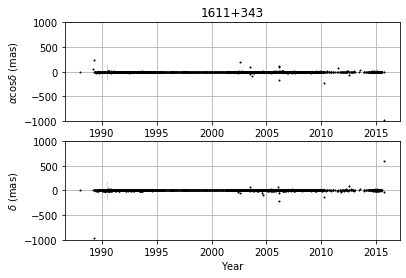

In [7]:
plt.subplot(211)
plt.title('1611+343')
plt.errorbar(df_sel['BY'], df_sel['RAcosDEC']/1000,yerr=df_sel['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel['BY'], df_sel['Dec. (mas)'], yerr=df_sel['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [8]:
df_sel_ra = allanself.remove_outliers(df_sel,'RA')
df_sel_dec = allanself.remove_outliers(df_sel,'DEC')

/home/anto/Research/Davendra/radio-sources/allanself.py:64: RuntimeWarning: invalid value encountered in double_scalars
  return sum(w[i]*(y[i]-ywbar)**2 for i in range(N))/((1-1/Np)*sum(w[i] for i in range(N)))


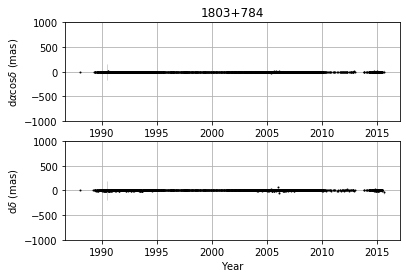

In [9]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df_sel_ra['BY'], df_sel_ra['RAcosDEC']/1000,yerr=df_sel_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel_dec['BY'], df_sel_dec['Dec. (micas)']/1000, yerr=df_sel_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

In [9]:
radec_std = np.sqrt(allanself.wvar(df_sel_ra['RAcosDEC'].values/1000,1/(df_sel_ra['Err. R.A. (micas)'].values/1000)**2))
radec_std

0.5040185433539377

In [10]:
dec_std = np.sqrt(allanself.wvar(df_sel_dec['Dec. (micas)'].values/1000,1/(df_sel_dec['Err. Dec. (micas)'].values/1000)**2))
dec_std

1.0531916571289561

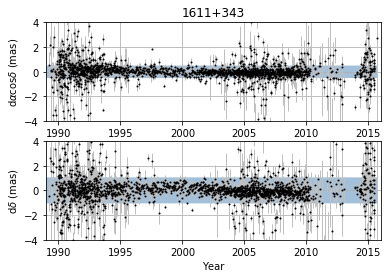

In [176]:
plt.subplot(211)
plt.title('1611+343')
plt.errorbar(df_sel_ra['BY'], df_sel_ra['RAcosDEC']/1000,yerr=df_sel_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_sel_ra['BY'], (-radec_std), (radec_std), facecolor='steelblue', alpha=0.5)
plt.ylim(-4,4)
plt.xlim(1989,2016)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel_dec['BY'], df_sel_dec['Dec. (micas)']/1000, yerr=df_sel_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='silver', elinewidth=1)
plt.fill_between(df_sel_dec['BY'], (-dec_std), (dec_std), facecolor='steelblue', alpha=0.5)
plt.ylim(-4,4)
plt.xlim(1989,2016)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

# OADEV

In [15]:
# %%time
# tau_dec, allanstd_dec = allanself.allanoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

# np.savetxt('1611+343_tau_dec.txt',tau_dec)
# np.savetxt('1611+343_allanstd_dec.txt',allanstd_dec)

CPU times: user 3min 21s, sys: 13.9 ms, total: 3min 21s
Wall time: 3min 21s


In [16]:
# %%time
# tau_ra, allanstd_ra = allanself.allanoadev(df_sel_ra['RAcosDEC'].values,df_sel_ra['MJD'].values,df_sel_ra['Err. R.A. (micas)'].values)

# np.savetxt('1611+343_tau_ra.txt',tau_ra)
# np.savetxt('1611+343_allanstd_ra.txt',allanstd_ra)

CPU times: user 3min 12s, sys: 12 ms, total: 3min 12s
Wall time: 3min 12s


In [17]:
tau_dec = np.loadtxt('1611+343_tau_dec.txt')
allanstd_dec = np.loadtxt('1611+343_allanstd_dec.txt')

In [18]:
tau_ra = np.loadtxt('1611+343_tau_ra.txt')
allanstd_ra = np.loadtxt('1611+343_allanstd_ra.txt')

In [19]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_low, ci_dec_high = allanself.confidence_int(df_sel_dec['Dec. (micas)'].values,df_sel_dec['Err. Dec. (micas)'].values,allanstd_dec,modified=False,overlapping=True,devtype='allan')

In [20]:
ci_ra_low, ci_ra_high = allanself.confidence_int(df_sel_ra['RAcosDEC'].values,df_sel_ra['Err. R.A. (micas)'].values,allanstd_ra,modified=False,overlapping=True,devtype='allan')

In [21]:
tau_dec_year = [x/365.242198781 for x in tau_dec]
tau_ra_year = [x/365.242198781 for x in tau_ra]

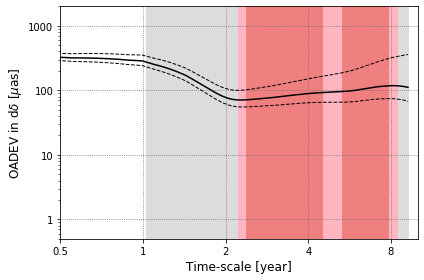

In [172]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
tau_dec_year = np.array(tau_dec_year)
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 0.1, 10**4, where= (tau_dec_year[:-1] > 1) & (slopes_dec < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**4, where= (tau_dec_year[:-1] > 1) &(-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 0.1, 10**4, where= (tau_dec_year[:-1] > 1) & (slopes_dec  > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, ci_dec_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',basex = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,2*10**3)
plt.xlim(0.5,10)
plt.tight_layout()

In [115]:
[np.size(tau_ra_year),np.size(slopes_ra)]

[628, 627]

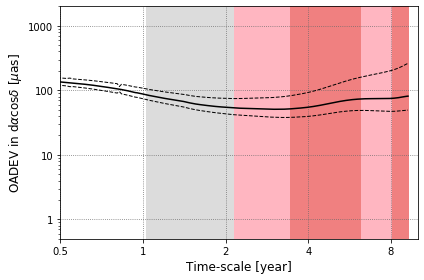

In [158]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra)) / np.diff(np.log10(tau_ra))
tau_ra_year = np.array(tau_ra_year)

# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 0.1, 10**4, where= (tau_ra_year[:-1] > 1) & (slopes_ra  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)

plt.fill_between(tau_ra_year[1:], 0.1, 10**4, where= (tau_ra_year[:-1] > 1) & (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 0.1, 10**4, where= (tau_ra_year[:-1] > 1) & (slopes_ra  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_year, ci_ra_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_year, ci_ra_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xlabel('Time-scale [year]', fontsize=12)
plt.xscale('log',basex = 2)
plt.ylabel(r'OADEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.ylim(0.5,2*10**3)
plt.xlim(0.5,10)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.tight_layout()

# OHDEV

In [33]:
def hadoadev(y,t,error):
        
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Initial sampling time
    tau0 =  np.mean(np.diff(t))
    # Steps
    step = tau0
    
    # Empty variance array
    hadvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        print('===> Current value of m:', m[k])
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print('M, D =', M, D)
        
        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < abs(M-3*m[k]+1-D):
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+2*m[k]]-2*ybar[i+m[k]]+ybar[i])
                i += 1
            outersum.append((np.sum(innersum)/m[k])**2)
            j += 1
            
        # Calculate allan variance
        print('Outer sum =', np.sum(outersum))

        print('M-3m+1-D =', M-3*m[k]+1-D)
        hadvar.append(np.sum(outersum)/(6*(M-3*m[k]+1-D)))
        
        # Calculate tau
        tau.append(tau0*m[k])
                
    # Calculate allan std dev
    hadstd = np.sqrt(hadvar)
        
    return tau, hadstd

In [42]:
def hadoadev_m(y,t,error):
        
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.array([480,481])
    # Initial sampling time
    tau0 =  np.mean(np.diff(t))
    # Steps
    step = tau0
    
    # Empty variance array
    hadvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        print('===> Current value of m:', m[k])
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print('M, D =', M, D)
        
        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        print(f"ybar size is {np.size(ybar)} \n"
              "m size is: {np.size(m)} \n"
                "k value is {k}")
        j = 0
        while j < abs(M-3*m[k]+1-D):
            print('j value =', j)
            i = j
            innersum = []
            while i <= j+m[k]-1:
                print('i value =', i)
                innersum.append(ybar[i+2*m[k]]-2*ybar[i+m[k]]+ybar[i])
                i += 1
            print('Inner sum =',np.sum(innersum))
            outersum.append((np.sum(innersum)/m[k])**2)
            j += 1
            
        # Calculate allan variance
        print('Outer sum =', np.sum(outersum))

        print('M-3m+1-D =', M-3*m[k]+1-D)
        hadvar.append(np.sum(outersum)/(6*(M-3*m[k]+1-D)))
        
        # Calculate tau
        tau.append(tau0*m[k])
                
    # Calculate allan std dev
    hadstd = np.sqrt(hadvar)
        
    return tau, hadstd

In [43]:
%%time
tau_dec_had_m, hadstd_dec_m = hadoadev_m(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

===> Current value of m: 480
M, D = 1441 0
ybar size is 1441 
m size is: {np.size(m)} 
k value is {k}
j value = 0
i value = 0
i value = 1
i value = 2
i value = 3
i value = 4
i value = 5
i value = 6
i value = 7
i value = 8
i value = 9
i value = 10
i value = 11
i value = 12
i value = 13
i value = 14
i value = 15
i value = 16
i value = 17
i value = 18
i value = 19
i value = 20
i value = 21
i value = 22
i value = 23
i value = 24
i value = 25
i value = 26
i value = 27
i value = 28
i value = 29
i value = 30
i value = 31
i value = 32
i value = 33
i value = 34
i value = 35
i value = 36
i value = 37
i value = 38
i value = 39
i value = 40
i value = 41
i value = 42
i value = 43
i value = 44
i value = 45
i value = 46
i value = 47
i value = 48
i value = 49
i value = 50
i value = 51
i value = 52
i value = 53
i value = 54
i value = 55
i value = 56
i value = 57
i value = 58
i value = 59
i value = 60
i value = 61
i value = 62
i value = 63
i value = 64
i value = 65
i value = 66
i value = 67
i value = 68

IndexError: index 1440 is out of bounds for axis 0 with size 1440

In [44]:
[np.size(df_sel_dec['Dec. (micas)'].values),
np.size(df_sel_dec['MJD'].values),
np.size(df_sel_dec['Err. Dec. (micas)'].values)]

[1921, 1921, 1921]

In [ ]:
%%time
tau_dec_had, hadstd_dec = hadoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

===> Current value of m: 3
M, D = 1918 964
Outer sum = 1086583104.442034
M-3m+1-D = 946
===> Current value of m: 4
M, D = 1917 707
Outer sum = 1115630794.031267
M-3m+1-D = 1199
===> Current value of m: 5
M, D = 1916 594
Outer sum = 999991446.5166235
M-3m+1-D = 1308
===> Current value of m: 6
M, D = 1915 484
Outer sum = 930998536.8833443
M-3m+1-D = 1414
===> Current value of m: 7
M, D = 1914 402
Outer sum = 839091202.4731779
M-3m+1-D = 1492
===> Current value of m: 8
M, D = 1913 336
Outer sum = 829206862.6096015
M-3m+1-D = 1554
===> Current value of m: 9
M, D = 1912 315
Outer sum = 797710650.5057576
M-3m+1-D = 1571
===> Current value of m: 10
M, D = 1911 291
Outer sum = 798703620.3779861
M-3m+1-D = 1591
===> Current value of m: 11
M, D = 1910 266
Outer sum = 908525298.7675521
M-3m+1-D = 1612
===> Current value of m: 12
M, D = 1909 243
Outer sum = 1045740630.614759
M-3m+1-D = 1631
===> Current value of m: 13
M, D = 1908 220
Outer sum = 1185391288.768608
M-3m+1-D = 1650
===> Current value

In [161]:
# %%time
# tau_ra_had, hadstd_ra = hadoadev(df_sel_ra['RAcosDEC'].values,df_sel_ra['MJD'].values,df_sel_ra['Err. R.A. (micas)'].values)

/home/anto/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:75: RuntimeWarning: invalid value encountered in double_scalars


CPU times: user 3min, sys: 7.18 ms, total: 3min
Wall time: 3min


In [162]:
# np.savetxt('1611+343_tau_dec_had.txt',tau_dec_had)
# np.savetxt('1611+343_hadstd_dec.txt',hadstd_dec)

# np.savetxt('1611+343_tau_ra_had.txt',tau_ra_had)
# np.savetxt('1611+343_hadstd_ra.txt',hadstd_ra)

In [177]:
tau_dec_had = np.loadtxt('1611+343_tau_dec_had.txt')
hadstd_dec = np.loadtxt('1611+343_allanstd_dec.txt')

tau_ra_had = np.loadtxt('1611+343_tau_ra_had.txt')
hadstd_ra = np.loadtxt('1611+343_hadstd_ra.txt')

In [164]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_had_low, ci_dec_had_high = allanself.confidence_int(df_sel_dec['Dec. (micas)'].values,df_sel_dec['Err. Dec. (micas)'].values,hadstd_dec,modified=False,overlapping=True,devtype='hadamard')

In [165]:
ci_ra_had_low, ci_ra_had_high = allanself.confidence_int(df_sel_ra['RAcosDEC'].values,df_sel_ra['Err. R.A. (micas)'].values,hadstd_ra,modified=False,overlapping=True,devtype='hadamard')

In [166]:
tau_dec_had_year = np.array([x/365.242198781 for x in tau_dec_had])
tau_ra_had_year = np.array([x/365.242198781 for x in tau_ra_had])

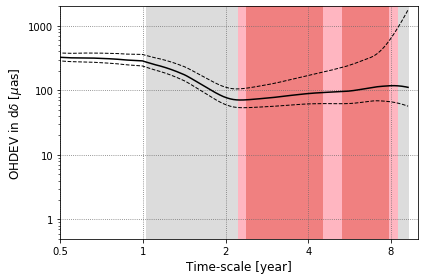

In [173]:
plt.figure()
# Calculate the slopes
slopes_dec_had = np.diff(np.log10(hadstd_dec)) / np.diff(np.log10(tau_dec_had))
# Plot hadamard std
plt.plot(tau_dec_had_year,hadstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**4, where= (tau_dec_had_year[:-1] > 1) & (slopes_dec_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**4, where= (tau_dec_had_year[:-1] > 1) &(-0.25 <= slopes_dec_had ) & (slopes_dec_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_dec_had_year[1:], 0.1, 10**4, where= (tau_dec_had_year[:-1] > 1) & (slopes_dec_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_had_year, ci_dec_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_had_year, ci_dec_had_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',basex = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OHDEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,2*10**3)
plt.xlim(0.5,10)
plt.tight_layout()

/home/anto/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


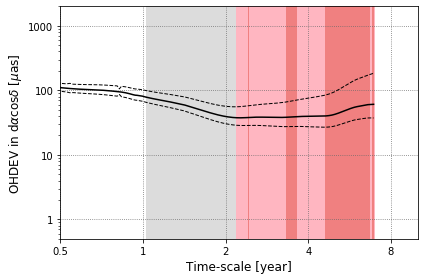

In [170]:
plt.figure()
# Calculate the slopes
slopes_ra_had = np.diff(np.log10(hadstd_ra)) / np.diff(np.log10(tau_ra_had))
# Plot allanstd
plt.plot(tau_ra_had_year,hadstd_ra,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**4, where= (tau_ra_had_year[:-1] > 1) & (slopes_ra_had  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**4, where= (tau_ra_had_year[:-1] > 1) & (-0.25 <= slopes_ra_had ) & (slopes_ra_had  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 0.1, 10**4, where= (tau_ra_had_year[:-1] > 1) & (slopes_ra_had  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_ra_had_year, ci_ra_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_ra_had_year, ci_ra_had_high,color='black',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xlabel('Time-scale [year]', fontsize=12)
plt.xscale('log',basex = 2)
plt.ylabel(r'OHDEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.ylim(0.5,2*10**3)
plt.xlim(0.5,10)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.tight_layout()

In [171]:
hadstd_ra

array([254.6295071 , 220.24567053, 203.23145446, 187.33188181,
       171.94578142, 169.23910947, 173.43971186, 177.48185326,
       181.50502527, 188.41217533, 196.72720748, 191.04228219,
       187.90943582, 183.11763648, 177.22819472, 170.51591498,
       164.34816759, 157.78098609, 151.13829702, 144.80143513,
       139.14804921, 134.45983602, 130.61443407, 127.58634359,
       124.9082935 , 122.58024353, 120.55896772, 118.48028556,
       116.34003374, 114.00410178, 112.0146817 , 110.32603412,
       109.00093806, 107.78839449, 106.73068932, 105.79158723,
       105.02282897, 104.35184455, 103.85898031, 103.46049334,
       103.13281031, 102.79584934, 102.36821427, 101.88276218,
       101.34801818, 100.78532922, 100.13327928,  99.46346461,
        98.7469919 ,  98.0029766 ,  97.23975327,  96.49272175,
        95.72038325,  94.90808656,  93.99962124,  92.93720308,
        91.68256676,  90.24064702,  88.63127383,  86.84428847,
        85.33812172,  84.12570601,  83.70144459,  82.81